# Train CNN with with Colab (GPU)

## Mounting to google colab, loading from google drive, paths...

In [1]:
from pathlib import Path
import sys
import os
import numpy as np


try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive") # mount the drive
    DATA_PATH = Path("/content/drive/MyDrive") # the root of the drive
    DATA_ROOT = DATA_PATH / "cbc_pe_data" # the root of the data
else:
    PROJECT_ROOT = Path.cwd().parent
    sys.path.insert(0, str(PROJECT_ROOT))
    DATA_ROOT = PROJECT_ROOT / "data"


DATA_RAW = DATA_ROOT / "raw" # the root of the raw data
DATA_PROCESSED = DATA_ROOT / "processed" # the root of the processed data
MODELS_DIR = DATA_ROOT / "models" # the root of the models
RESULTS_DIR = DATA_ROOT / "results" # the root of the results
CHECKPOINTS_DIR = MODELS_DIR / "checkpoints" # the root of the checkpoints

for path in [DATA_RAW, DATA_PROCESSED, MODELS_DIR, RESULTS_DIR, CHECKPOINTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("DATA_RAW:", DATA_RAW)
print("MODELS_DIR:", MODELS_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("CHECKPOINTS_DIR:", CHECKPOINTS_DIR)



#Clone the repository if it doesn't exist
if IN_COLAB:
    REPO_ROOT = Path("/content/Gravitational-Waves-Lab")
    PROJECT_ROOT = REPO_ROOT / "cbc_pe"

    if not REPO_ROOT.exists():
        !git clone https://github.com/victorsh13/Gravitational-Waves-Lab.git /content/Gravitational-Waves-Lab

    print("REPO_ROOT exists:", REPO_ROOT.exists())
    print("PROJECT_ROOT exists:", PROJECT_ROOT.exists())

    #Pull the latest version of the repository
    %cd /content/Gravitational-Waves-Lab
    !git pull
    !git status

    #Go to the project root
    %cd /content/Gravitational-Waves-Lab/cbc_pe
else:
    %cd /home/victor/gw/cbc_pe
    


# Add the project root to the python path
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("cwd:", Path.cwd())
print("sys.path[:3]:", sys.path[:3])

DATA_ROOT: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/data
DATA_RAW: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/data/raw
MODELS_DIR: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/data/models
RESULTS_DIR: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/data/results
CHECKPOINTS_DIR: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/data/models/checkpoints
[Errno 2] No such file or directory: '/home/victor/gw/cbc_pe'
/afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/notebooks
cwd: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe
sys.path[:3]: ['/afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe', '/afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/notebooks', '/opt/utils']


/afs/ciemat.es/user/v/vserrano/miniconda3/envs/gw-env/lib/python3.10/site-packages/IPython/core/magics/osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


## Load the data

In [2]:
from src.io import load_dataset_npz

dataset_path = DATA_RAW / "cbc_dataset_5000.npz"

print(dataset_path.exists())

batch = load_dataset_npz(dataset_path)

X = batch.X
y = batch.y
network_snrs = batch.network_snrs   
metadata = batch.metadata


True


## Split data into (train, val) and (train, test)

Split the data into:
- ``train``       : training the model
- ``val``         : early stopping / chosing the best model
- ``calibration`` : calibration of the conformal intervals
- ``test``        : final evaluation, independent of the model/training/calibration

Some reasonable splits: 70/10/10/10 

In [11]:
import numpy as np


n_samples = X.shape[0]
rng = np.random.default_rng(seed=13)

indices = rng.permutation(n_samples)
split_fractions = [0.7, 0.1, 0.1, 0.1] # Train, Val, Cal, Test


if not np.isclose(sum(split_fractions), 1):
    raise ValueError("Split fractions must sum to 1")

n_train = int(split_fractions[0] * n_samples)
n_val = int(split_fractions[1] * n_samples)
n_cal = int(split_fractions[2] * n_samples)
n_test = n_samples - n_train - n_val - n_cal

print(f"Samples: \n - Train: {n_train}\n - Val: {n_val}\n - Cal: {n_cal}\n - Test: {n_test}")

idx_train = indices[:n_train]
idx_val = indices[n_train:n_train+n_val]
idx_cal = indices[n_train+n_val:n_train+n_val+n_cal]
idx_test = indices[n_train+n_val+n_cal:]

# Save splits to compare models properly
np.savez(
    DATA_PROCESSED / "splits_cbc_dataset_5000.npz",
    idx_train=idx_train,
    idx_val=idx_val,
    idx_cal=idx_cal,
    idx_test=idx_test,
)


X_train, y_train = X[idx_train], y[idx_train]
X_val, y_val = X[idx_val], y[idx_val]
X_cal, y_cal = X[idx_cal], y[idx_cal]
X_test, y_test = X[idx_test], y[idx_test]





Samples: 
 - Train: 3500
 - Val: 500
 - Cal: 500
 - Test: 500


## Label Standardization

Standarize the labels using the mean and standard deviation of the training set and save it in DATA_PROCESSED.
This will be needed to revert the normalization and interpret the predictions as physical quantities.

In [12]:
y_mean = y_train.mean(axis=0)
y_std = y_train.std(axis=0) + 1e-8

y_train_std = (y_train - y_mean) / y_std
y_val_std = (y_val - y_mean) / y_std
y_cal_std = (y_cal - y_mean) / y_std
y_test_std = (y_test - y_mean) / y_std


# Save it in file:
file_name_std = "standardization_params_5000.npz"

np.savez(
    DATA_PROCESSED / file_name_std,
    mean=y_mean,
    std=y_std,
)

## Datasets & DataLoaders

Create PyTorch datasets

In [14]:
from src.models.dataset import ArrayRegressionDataset

train_dataset = ArrayRegressionDataset(X_train, y_train_std)
val_dataset = ArrayRegressionDataset(X_val, y_val_std)
cal_dataset = ArrayRegressionDataset(X_cal, y_cal_std)
test_dataset = ArrayRegressionDataset(X_test, y_test_std)

And loaders

In [15]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
)

cal_loader = DataLoader(
    cal_dataset,
    batch_size=batch_size,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
)

## Train the CNN and save the model

Function to train the CNN

In [ ]:
from src.models.train import train_model
from src.models.network import SimpleCNN
from src.models.utils import set_seed
import torch 

seed = 13
set_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_config = {
    "architecture": "SimpleCNN_GN_v1",
    "n_detectors": 3,
    "n_outputs": 3,
    "embedding_dim": 64,
    "dropout_conv": 0.05,
    "dropout_dense": 0.1,
    "normalization": "GroupNorm",
    "activation_conv": "LeakyReLU(0.01)",
    "activation_dense": "LeakyReLU(0.1)",
}


model = SimpleCNN(
    n_detectors=model_config["n_detectors"],
    n_outputs=model_config["n_outputs"],
    embedding_dim=model_config["embedding_dim"],
    dropout_conv=model_config["dropout_conv"],
    dropout_dense=model_config["dropout_dense"],
).to(device)


best_checkpoint, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    y_mean=y_mean,
    y_std=y_std,
    model_config=model_config,
    seed=seed,
    batch_size=batch_size,
    max_epochs=100,
    patience=15,
    learning_rate=3e-4,
    weight_decay=1e-4,
)

print("Best epoch:", best_checkpoint["epoch"])
print("Best val loss:", best_checkpoint["best_val_loss"])

Save the best checkpoint

In [ ]:
checkpoint_file_name = (
    f"SimpleCNN_GN_v1_"
    f"N5000_"
    f"seed{seed}_"
    f"bestval{best_checkpoint['best_val_loss']:.4f}.pt"
)

checkpoint_path = CHECKPOINTS_DIR / checkpoint_file_name

torch.save(best_checkpoint, checkpoint_path)

print("Saved checkpoint to:", checkpoint_path)

## Load model from best checkpoint

In [17]:
import torch
from src.models.network import SimpleCNN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_file_name = "SimpleCNN_GN_v1_N5000_seed13_bestval0.5850.pt"

checkpoint_path = CHECKPOINTS_DIR / checkpoint_file_name

checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
)

config = checkpoint["model_config"]

model = SimpleCNN(
    n_detectors=config["n_detectors"],
    n_outputs=config["n_outputs"],
    embedding_dim=config["embedding_dim"],
    dropout_conv=config["dropout_conv"],
    dropout_dense=config["dropout_dense"],
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

y_mean_loaded = checkpoint["y_mean"].cpu().numpy()
y_std_loaded = checkpoint["y_std"].cpu().numpy()

print("Loaded epoch:", checkpoint["epoch"])
print("Loaded val loss:", checkpoint["best_val_loss"])

Loaded epoch: 63
Loaded val loss: 0.5849796657562256


## Save metrics in json

Save metrics in a json file

In [19]:
import json

seed = 13
best_checkpoint = checkpoint

metrics = {
    "checkpoint_file": checkpoint_file_name,
    "seed": seed,
    "best_epoch": int(best_checkpoint["epoch"]),
    "train_loss_at_best": float(best_checkpoint["train_loss"]),
    "val_loss_at_best": float(best_checkpoint["best_val_loss"]),
    "model_config": best_checkpoint["model_config"],
    "training_config": best_checkpoint["training_config"],
    "elapsed_seconds": float(best_checkpoint["elapsed_seconds"]),
    "history": best_checkpoint["history"],
}

metrics_path = RESULTS_DIR / checkpoint_file_name.replace(".pt", "_metrics.json")

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)

print("Saved metrics to:", metrics_path)

Saved metrics to: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/data/results/SimpleCNN_GN_v1_N5000_seed13_bestval0.5850_metrics.json


Check and save values for val(test)

In [18]:
from src.models.evaluate import predict_on_loader, compute_error_metrics

label_names = ["chirp_mass", "total_mass", "chi_eff"]


pred_val, y_val = predict_on_loader(model, val_loader, device)
error_metrics_val = compute_error_metrics(pred_val, y_val, label_names)


for i, name in enumerate(label_names):
    print(f"{name}")
    print(f"  val  MSE={error_metrics_val['per_label'][name]['mse']:.4f}, MAE={error_metrics_val['per_label'][name]['mae']:.4f}")
    

chirp_mass
  val  MSE=0.4954, MAE=0.5461
total_mass
  val  MSE=0.3927, MAE=0.4946
chi_eff
  val  MSE=0.8669, MAE=0.7669


Add it to the json file

In [20]:
metrics["val_mse_per_label"] = {
    name: float(error_metrics_val["per_label"][name]["mse"]) for name in label_names
}

metrics["val_mae_per_label"] = {
    name: float(error_metrics_val["per_label"][name]["mae"]) for name in label_names
}

metrics["val_loss_global_mse"] = error_metrics_val["global_mse"]
metrics["val_loss_global_mae"] = error_metrics_val["global_mae"]
 

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)

Structure:
checkpoint .pt  -> weights + scaler + config
metrics .json     -> resultados legibles

## Repeat for several seeds

In [ ]:
from src.models.utils import set_seed

seeds = [13, 21, 42]

all_results = []

for seed in seeds:
    set_seed(seed)

    model = SimpleCNN(
        n_detectors=3,
        n_outputs=3,
        embedding_dim=64,
        dropout_conv=0.05,
        dropout_dense=0.1,
    ).to(device)

    model_config = {
        "architecture": "SimpleCNN_GN_v1",
        "n_detectors": 3,
        "n_outputs": 3,
        "embedding_dim": 64,
        "dropout_conv": 0.05,
        "dropout_dense": 0.1,
        "normalization": "GroupNorm",
        "activation_conv": "LeakyReLU(0.01)",
        "activation_dense": "LeakyReLU(0.1)",
        "seed": seed,
    }

    best_checkpoint, history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        y_mean=y_mean,
        y_std=y_std,
        model_config=model_config,
        max_epochs=100,
        patience=15,
        learning_rate=3e-4,
        weight_decay=1e-4,
    )

    checkpoint_file_name = (
        f"SimpleCNN_GN_v1_"
        f"N5000_"
        f"seed{seed}_"
        f"bestval{best_checkpoint['val_loss']:.4f}.pt"
    )

    checkpoint_path = CHECKPOINTS_DIR / checkpoint_file_name
    torch.save(best_checkpoint, checkpoint_path)

    all_results.append({
        "seed": seed,
        "checkpoint": str(checkpoint_path),
        "best_epoch": int(best_checkpoint["epoch"]),
        "best_val_loss": float(best_checkpoint["val_loss"]),
    })

## Extraer predicciones y embeddings (After training)

Get the predictions, embeddings and labels for the calibration and test sets.

In [21]:
from src.models.evaluate import extract_predictions_and_embeddings

pred_cal, emb_cal, y_cal = extract_predictions_and_embeddings(
    model,
    cal_loader,
    device,
)

pred_test, emb_test, y_test = extract_predictions_and_embeddings(
    model,
    test_loader,
    device,
)

And the we save all the results (predictions, embeddings, labels) to use later in Mondrian.

In [22]:
embeddings_file = checkpoint_file_name.replace(".pt", "_predictions_embeddings.npz")

np.savez_compressed(
    RESULTS_DIR / embeddings_file,
    pred_cal=pred_cal,
    emb_cal=emb_cal,
    y_cal=y_cal,
    pred_test=pred_test,
    emb_test=emb_test,
    y_test=y_test,
    y_mean=y_mean,
    y_std=y_std,
    checkpoint_file=checkpoint_file_name,
)

print("Embeddings saved to:", RESULTS_DIR / embeddings_file)

Embeddings saved to: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/data/results/SimpleCNN_GN_v1_N5000_seed13_bestval0.5850_predictions_embeddings.npz


## Plots

Plot the predictions vs the true values of the validation set

In [23]:
from src.models.evaluate import predict_on_loader

pred_val_std, y_val_std = predict_on_loader(
    model,
    val_loader,
    device,
)


y_mean = checkpoint["y_mean"].cpu().numpy()
y_std = checkpoint["y_std"].cpu().numpy()

pred_val = pred_val_std * y_std + y_mean
y_val_true = y_val_std * y_std + y_mean

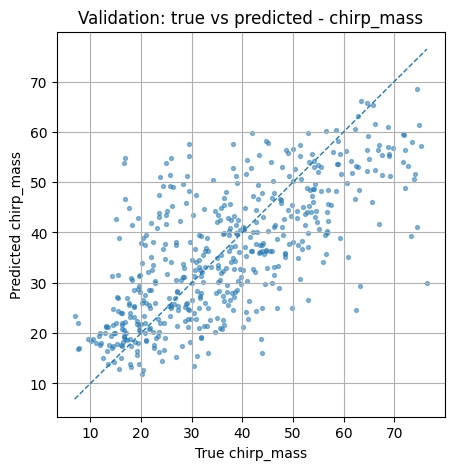

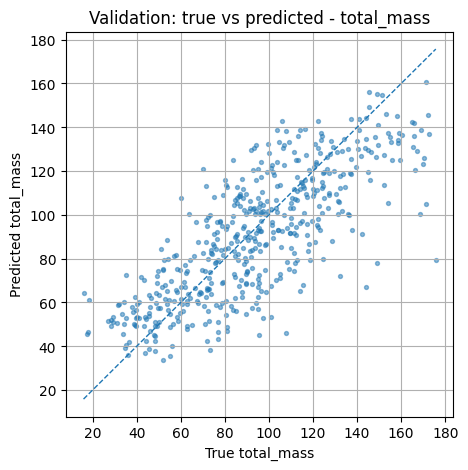

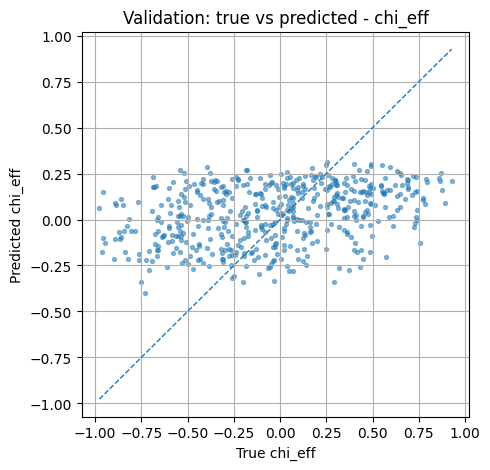

In [24]:
#Plot pred vs true for the 3 labels (chirp_mass, total_mass, chi_eff)
import matplotlib.pyplot as plt
import numpy as np

label_names = ["chirp_mass", "total_mass", "chi_eff"]

for j, name in enumerate(label_names):
    plt.figure(figsize=(5, 5))

    plt.scatter(
        y_val_true[:, j],
        pred_val[:, j],
        s=8,
        alpha=0.5,
    )

    min_val = min(y_val_true[:, j].min(), pred_val[:, j].min())
    max_val = max(y_val_true[:, j].max(), pred_val[:, j].max())

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--",
        linewidth=1,
    )

    plt.xlabel(f"True {name}")
    plt.ylabel(f"Predicted {name}")
    plt.title(f"Validation: true vs predicted - {name}")
    plt.grid(True)
    plt.show()




Also plot the residuals

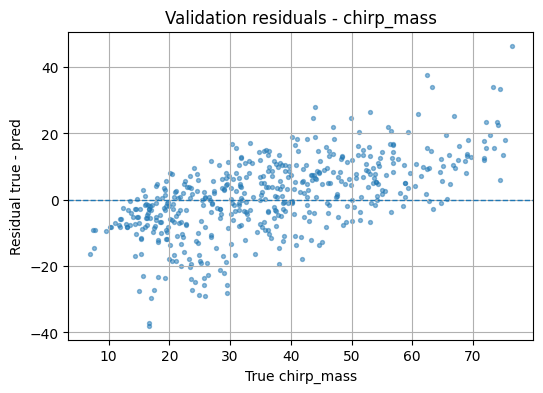

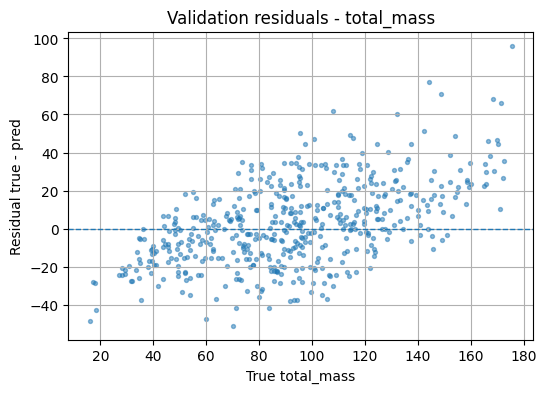

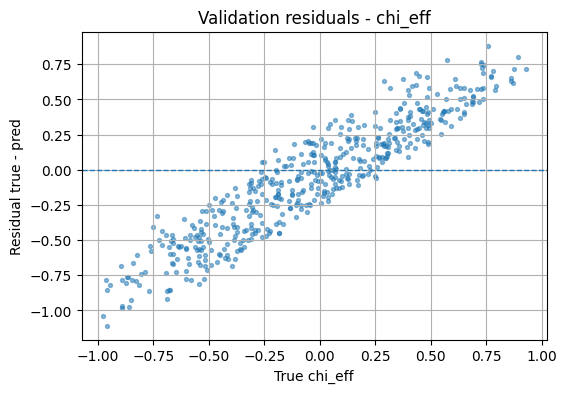

In [25]:
for j, name in enumerate(label_names):
    residual = y_val_true[:, j] - pred_val[:, j]

    plt.figure(figsize=(6, 4))

    plt.scatter(
        y_val_true[:, j],
        residual,
        s=8,
        alpha=0.5,
    )

    plt.axhline(0.0, linestyle="--", linewidth=1)

    plt.xlabel(f"True {name}")
    plt.ylabel(f"Residual true - pred")
    plt.title(f"Validation residuals - {name}")
    plt.grid(True)
    plt.show()

### Testing the GPU

In [26]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    props = torch.cuda.get_device_properties(0)
    print("Total VRAM [GB]:", props.total_memory / 1024**3)

CUDA available: False


In [27]:

print("Allocated [GB]:", torch.cuda.memory_allocated() / 1024**3)
print("Reserved [GB]:", torch.cuda.memory_reserved() / 1024**3)
print("Peak allocated [GB]:", torch.cuda.max_memory_allocated() / 1024**3)
print("Peak reserved [GB]:", torch.cuda.max_memory_reserved() / 1024**3)

Allocated [GB]: 0.0
Reserved [GB]: 0.0
Peak allocated [GB]: 0.0
Peak reserved [GB]: 0.0


In [28]:
def test_batch_size(model, batch_size, n_detectors=3, signal_length=16384, device="cuda"):
    try:
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

        model.train()

        X = torch.randn(batch_size, n_detectors, signal_length, device=device)
        y = torch.randn(batch_size, 3, device=device)

        optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
        loss_fn = torch.nn.MSELoss()

        optimizer.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()

        peak = torch.cuda.max_memory_allocated() / 1024**3
        print(f"batch_size={batch_size} OK | peak VRAM = {peak:.2f} GB")

        del X, y, pred, loss
        torch.cuda.empty_cache()

        return True

    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            print(f"batch_size={batch_size} OOM")
            torch.cuda.empty_cache()
            return False
        else:
            raise e

In [30]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

for bs in [32, 64, 96, 128, 192]:
    if device == "cuda":
        ok = test_batch_size(model, bs, device=device)
        if not ok:
            break